In [55]:
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
from ndlib.utils import multi_runs
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time # TODO: remove when done

## 2.1 Implement SIR and Simulate

Implement SIR disease spread on the network. Think about your experimental design
and which parameters of the model you will want to vary. Design code that will allow
you run multiple simulations while varying the disease parameter.

### Functions to generate network, model, and run SIR simulations

In [5]:
def create_network(network_type, num_nodes, seed = None, p = 0.01, m = 5, k = 6):
    if network_type == 'Erdos-Renyi':
        return nx.erdos_renyi_graph(num_nodes, p, seed)
    elif network_type == 'Barabasi-Albert':
        return nx.barabasi_albert_graph(num_nodes, m, seed)
    elif network_type == 'Watts-Strogatz':
        return nx.watts_strogatz_graph(num_nodes, k, p, seed)
    else:
        raise ValueError("Invalid network type. Choose from 'Erdos-Renyi', 'Barabasi-Albert', or 'Watts-Strogatz'.")

In [27]:
def generate_model(network, beta, gamma, initial_infected_fraction = None, initial_infected_nodes = None):
    # Create model
    model = ep.SIRModel(network)
    config = mc.Configuration()
    
    # Add model Parameters 
    config.add_model_parameter('beta', beta) 
    config.add_model_parameter('gamma', gamma)  

    # Set initial infected population (either by fraction or specific nodes)
    if initial_infected_fraction:
        config.add_model_parameter('percentage_infected', initial_infected_fraction)
    elif initial_infected_nodes:
        config.add_model_initial_configuration('Infected', initial_infected_nodes)
    
    model.set_initial_status(config)

    return model

In [96]:
def run_sir_simulations(network, beta, gamma, initial_infected_fraction = None, initial_infected_nodes = None, iterations = 100, num_simulations = 50):
    # Generate the model
    model = generate_model(network, beta, gamma, initial_infected_fraction, initial_infected_nodes)

    # Run the model and retund results
    if initial_infected_fraction:
        return multi_runs(model, execution_number = num_simulations, iteration_number = iterations, nprocesses=4)
    elif initial_infected_nodes:
        infection_sets = [initial_infected_nodes for _ in range(num_simulations)]
        return multi_runs(model, execution_number=num_simulations, iteration_number=iterations, infection_sets=infection_sets, nprocesses=4)
    else:
        raise ValueError("You need to provide either 'initial_infected_fraction' or 'initial_infected_nodes' parameter.")

## 2.2 Generate Networks of equivalent form

Using NetworkX generate multiple model networks with similar characteristics, again
think about the parameters associated with each network generator (e.g., Number of
nodes, connection probability,etc). Pick some network statistics (e.g., centrality measures,
degree distributions, etc.) that are interesting to measure in terms of spreading on the
network. You should generate multiple instances of each network type and then plot the
network statistics (you chose) and discuss how these statistic differ between network types
and for different parameter settings. You will use these generated networks in your SIR
experiments in the next part.

### Functions to measure basic network statistics

In [108]:
def get_diameter(network):
    return nx.diameter(network)

In [112]:
def get_average_path_length(network):
    return nx.average_shortest_path_length(network)

In [129]:
def get_average_clustering(network):
    return nx.average_clustering(network)

In [110]:
def get_average_degree(network):
    return 2 * network.number_of_edges() / network.number_of_nodes()

In [125]:
def show_degree_histogram(network, title = None):
    degree_histogram = nx.degree_histogram(network)

    degrees = range(len(degree_histogram))
    
    plt.bar(degrees, degree_histogram, color='lightgreen', edgecolor='black')
    
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    if title:
        plt.title(title)
    else:
        plt.title('Degree histogram')
    
    plt.show()

In [127]:
def show_degree_probability(network, title = None):
    degree_histogram = nx.degree_histogram(network)

    num_nodes = network.number_of_nodes()

    degree_probability = [frequency / num_nodes for frequency in degree_histogram]

    # Scatter plot of the probability
    plt.scatter(range(1, len(degree_histogram) + 1), degree_probability)

    plt.xlabel('Degree k')
    plt.ylabel('Probability p(k)')
    if title:
        plt.title(title)
    else:
        plt.title('Degree distribution')

    plt.show()

### Centrality measures

In [270]:
def get_average_degree_normalised(network):
    degree_centrality = nx.degree_centrality(network)
    
    return sum(c_d / num_nodes for c_d in degree_centrality.values())

In [274]:
def show_degree_centrality(network):
    degree_centrality = nx.degree_centrality(network)
    
    # Plot a histogram of degree centrality values
    plt.hist(list(degree_centrality.values()), bins=10, color='lightgreen', edgecolor='black')
    plt.title('Degree Centrality Distribution')
    plt.xlabel('Degree Centrality (normalised)')
    plt.ylabel('Frequency')
    plt.show()

In [276]:
def show_betweenness_centrality(network):
    betweenness_centrality = nx.betweenness_centrality(network)
    
    # Plot a histogram of betweenness centrality values
    plt.hist(list(betweenness_centrality.values()), bins=20, color='lightgreen', edgecolor='black')
    plt.title('Betweenness Centrality Distribution')
    plt.xlabel('Betweenness Centrality')
    plt.ylabel('Frequency')
    plt.show()

In [278]:
def show_betweenness_centrality(network):
    betweenness_centrality = nx.betweenness_centrality(network)
    
    # Plot a histogram of betweenness centrality values
    plt.hist(list(betweenness_centrality.values()), bins=20, color='lightgreen', edgecolor='black')
    plt.title('Betweenness Centrality Distribution')
    plt.xlabel('Betweenness Centrality')
    plt.ylabel('Frequency')
    plt.show()

### Generate multiple networks and show statistics

In [316]:
def print_basic_network_statistics(network):
    print('Diameter =', get_diameter(network))
    print('Average path length =', get_average_path_length(network))
    print('Average degree =', get_average_degree(network))
    print('Clustering coefficient =', get_average_clustering(network))
    print('Number of edges =', network.number_of_edges())
    print('------------------------------------')

In [283]:
def generate_multiple_networks(num_networks, network_type, num_nodes, seed, p = None, m = None, k = None):
    networks = []
    
    for n in range(num_networks):
        # Generate network
        network = create_network(network_type, num_nodes, seed = seed, p = p, k = k, m = m)
        networks.append(network)

        # Update seed
        seed += 1

    return networks

In [427]:
def plot_network_histograms(network, title):
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    
    # Plot degree histogram
    degree_histogram = nx.degree_histogram(network)
    degrees = range(len(degree_histogram))
    
    axs[0].bar(degrees, degree_histogram, color='darkolivegreen', edgecolor='black')
    axs[0].set_xlabel('Degree')
    axs[0].set_ylabel('Frequency')
    # axs[0].set_title('Degree Histogram')

    # Plot degree centrality
    degree_centrality = nx.degree_centrality(network)
    
    axs[1].hist(list(degree_centrality.values()), bins=10, color='olive', edgecolor='black')
    axs[1].set_xlabel('Degree Centrality (normalised)')
    axs[1].set_ylabel('Frequency')
    # axs[1].set_title('Degree Centrality Distribution')
    
    # Plot betweenness centrality
    betweenness_centrality = nx.betweenness_centrality(network)
    
    axs[2].hist(list(betweenness_centrality.values()), bins=20, color='goldenrod', edgecolor='black')
    axs[2].set_xlabel('Betweenness Centrality')
    axs[2].set_ylabel('Frequency')
    # axs[2].set_title('Betweenness Centrality Distribution')
    
    # Plot closeness centrality
    closeness_centrality = nx.closeness_centrality(network)
    
    axs[3].hist(list(closeness_centrality.values()), bins=20, color='palegoldenrod', edgecolor='black')
    axs[3].set_xlabel('Closeness Centrality')
    axs[3].set_ylabel('Frequency')
    # axs[3].set_title('Closeness Centrality Distribution')

    plt.tight_layout()
    plt.suptitle(title, fontsize=18)
    plt.subplots_adjust(top = 0.9)
    plt.show()

### Comparison of networks

#### Same average degree

Erdos-Renyi
Diameter = 4
Average path length = 2.643041041041041
Average degree = 19.856
Clustering coefficient = 0.019953987649373697
Number of edges = 9928
------------------------------------
Barabasi-Albert
Diameter = 4
Average path length = 2.5565685685685686
Average degree = 19.8
Clustering coefficient = 0.06249494541740752
Number of edges = 9900
------------------------------------
Watts-Strogatz
Diameter = 35
Average path length = 13.830742742742743
Average degree = 20.0
Clustering coefficient = 0.7094856307435254
Number of edges = 10000
------------------------------------


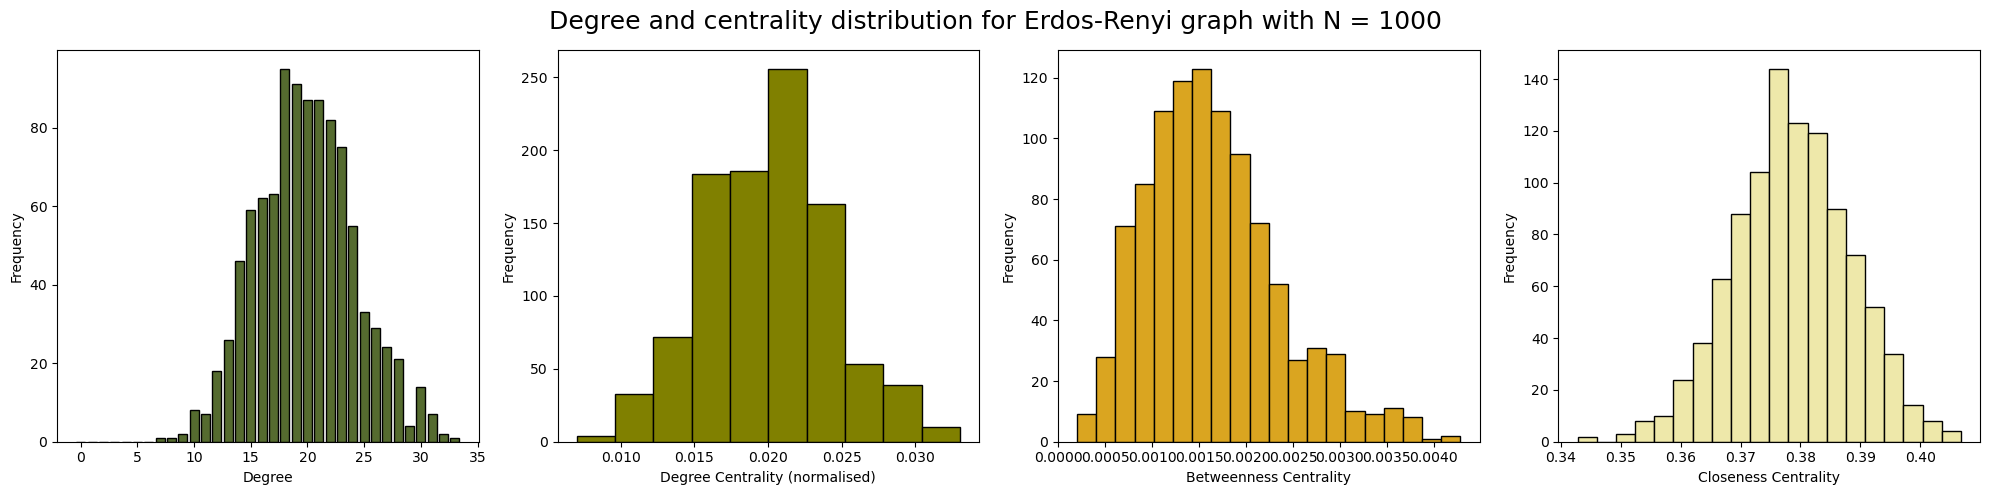

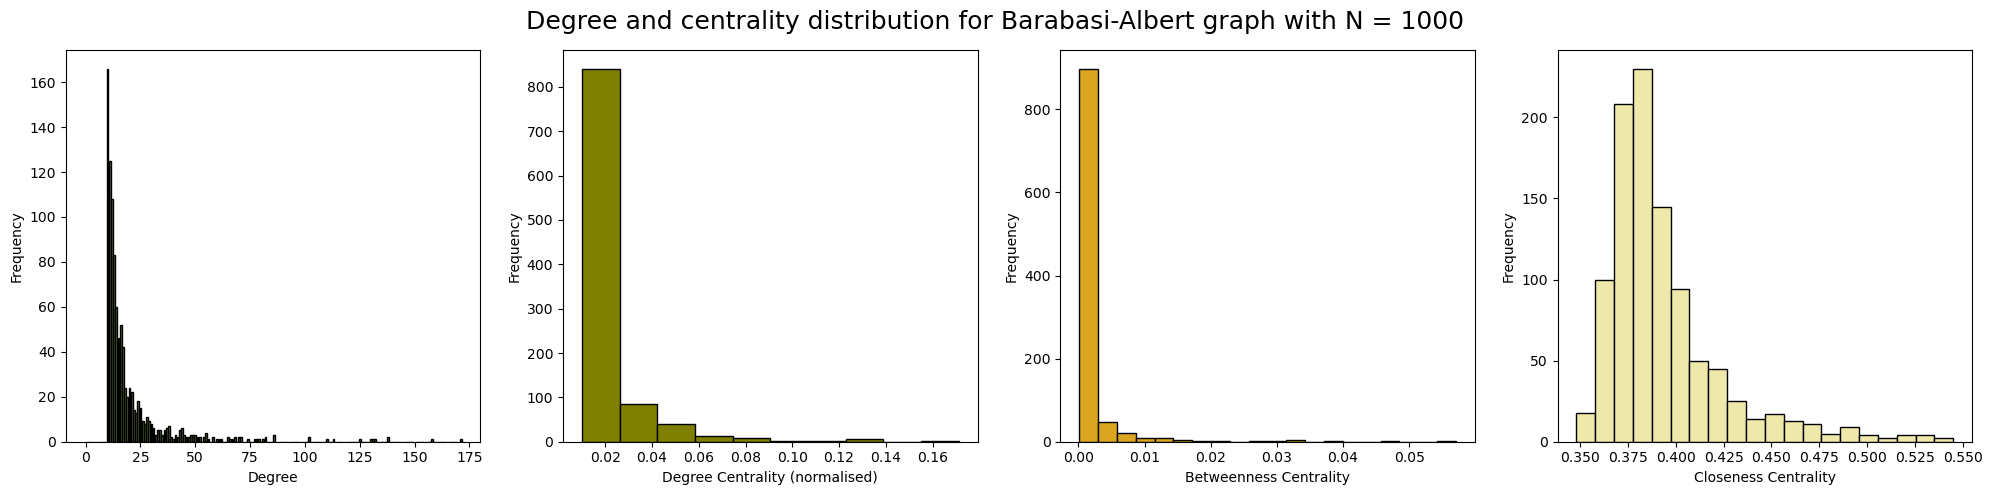

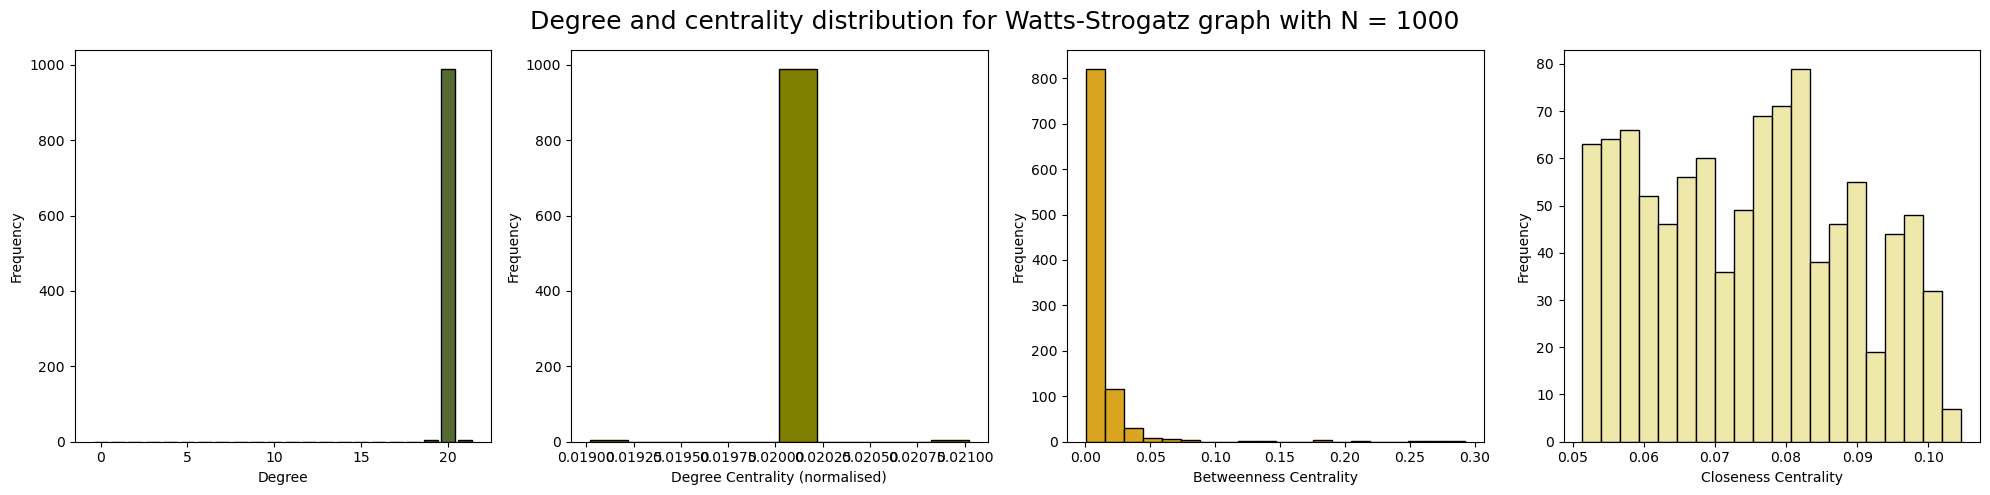

In [431]:
# Generate networks
seed = 10
num_nodes = 1000

# Erdos-Renyi
er_network = create_network('Erdos-Renyi', num_nodes, seed = seed, p = 0.02)

# Barabasi-Albert
ba_network = create_network('Barabasi-Albert', num_nodes, seed = seed, m = 10)

# Watts-Strogatz
ws_network = create_network('Watts-Strogatz', num_nodes, seed = seed, k = 20, p = 0.001)

# Print basic statistics
print('Erdos-Renyi')
print_basic_network_statistics(er_network)
print('Barabasi-Albert')
print_basic_network_statistics(ba_network)
print('Watts-Strogatz')
print_basic_network_statistics(ws_network)

# Plot histograms
plot_network_histograms(er_network, 'Degree and centrality distribution for Erdos-Renyi graph with N = 1000')
plot_network_histograms(ba_network, 'Degree and centrality distribution for Barabasi-Albert graph with N = 1000')
plot_network_histograms(ws_network, 'Degree and centrality distribution for Watts-Strogatz graph with N = 1000')

#### Heavily connected networks

Erdos-Renyi
Diameter = 3
Average path length = 1.9001561561561562
Average degree = 99.79
Clustering coefficient = 0.09973648605439032
Number of edges = 49895
------------------------------------
Barabasi-Albert
Diameter = 3
Average path length = 1.9070850850850851
Average degree = 95.0
Clustering coefficient = 0.17337389443014586
Number of edges = 47500
------------------------------------
Watts-Strogatz
Diameter = 5
Average path length = 3.0224844844844845
Average degree = 100.0
Clustering coefficient = 0.7408039053701289
Number of edges = 50000
------------------------------------


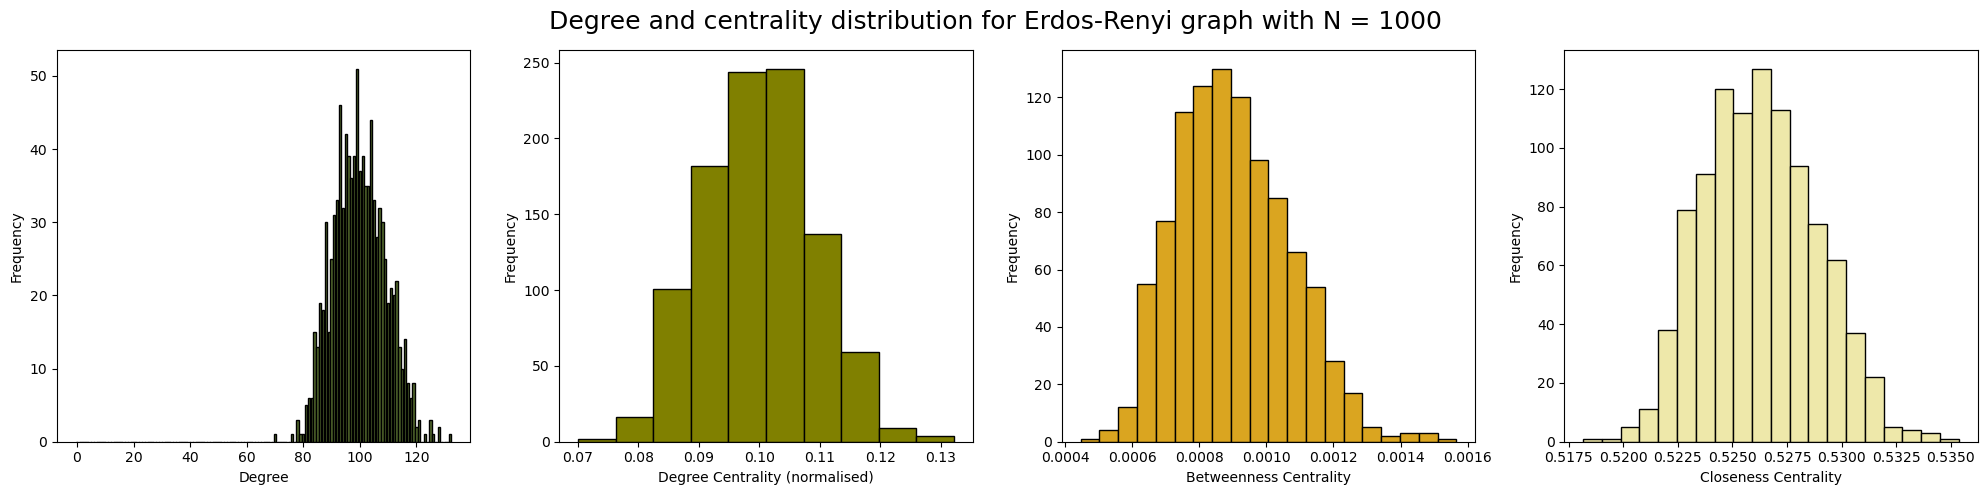

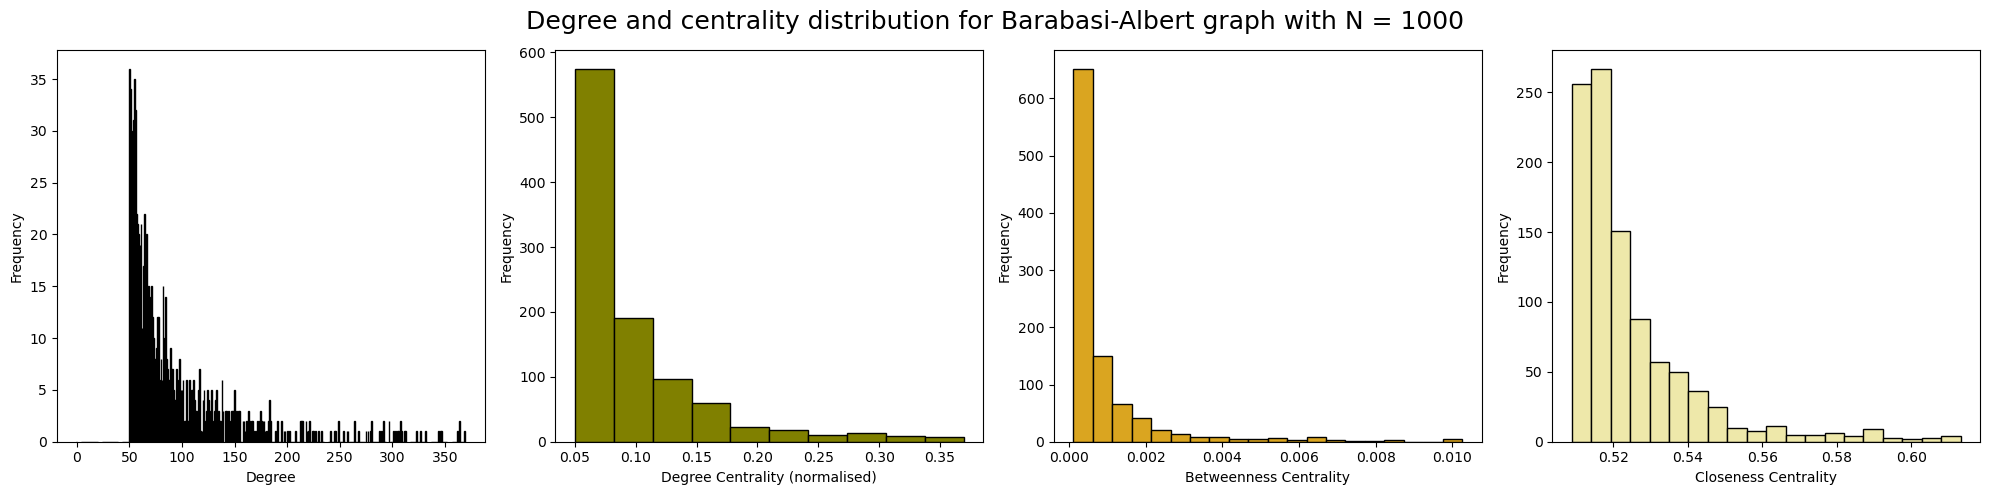

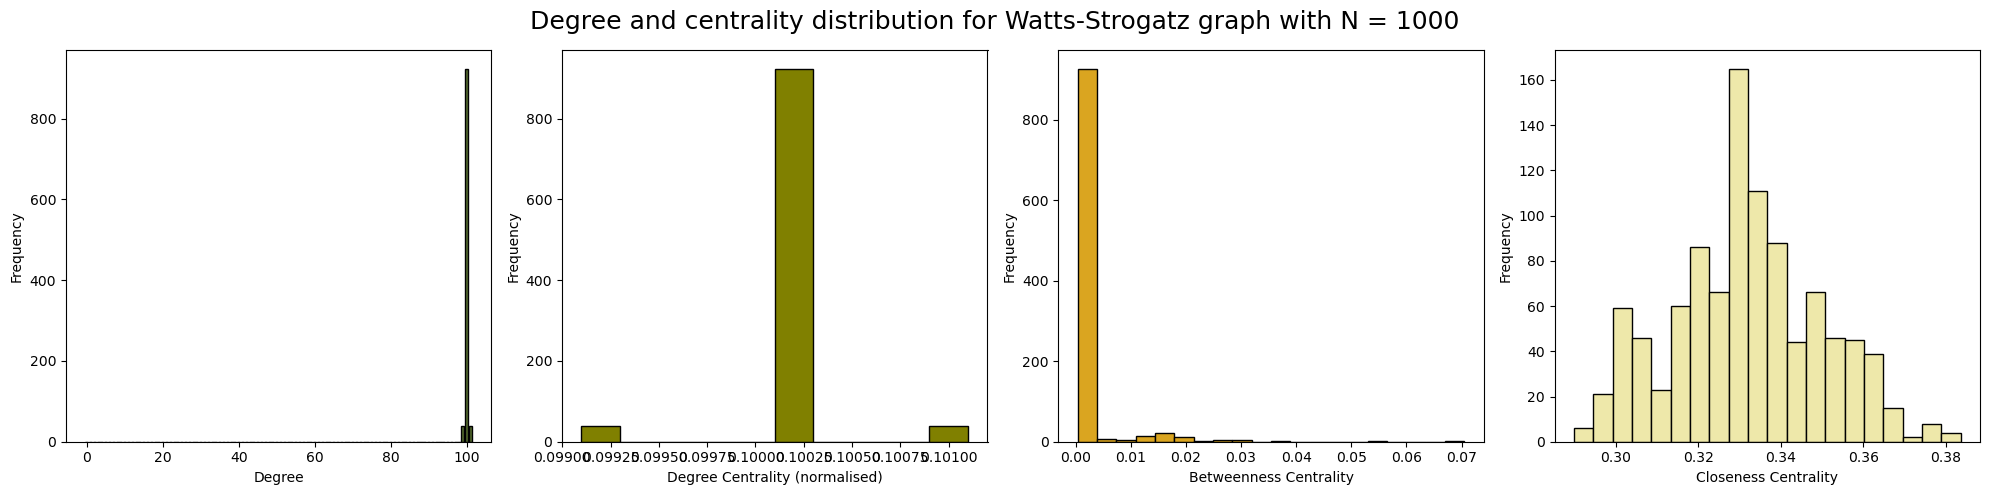

In [432]:
# Generate networks
seed = 10
num_nodes = 1000

# Erdos-Renyi
er_network = create_network('Erdos-Renyi', num_nodes, seed = seed, p = 0.1)

# Barabasi-Albert
ba_network = create_network('Barabasi-Albert', num_nodes, seed = seed, m = 50)

# Watts-Strogatz
ws_network = create_network('Watts-Strogatz', num_nodes, seed = seed, k = 100, p = 0.001)

# Show statistics
print('Erdos-Renyi')
print_basic_network_statistics(er_network)
print('Barabasi-Albert')
print_basic_network_statistics(ba_network)
print('Watts-Strogatz')
print_basic_network_statistics(ws_network)

# Plot histograms
plot_network_histograms(er_network, 'Degree and centrality distribution for Erdos-Renyi graph with N = 1000')
plot_network_histograms(ba_network, 'Degree and centrality distribution for Barabasi-Albert graph with N = 1000')
plot_network_histograms(ws_network, 'Degree and centrality distribution for Watts-Strogatz graph with N = 1000')

#### Small networks

Erdos-Renyi
Diameter = 5
Average path length = 2.6284848484848484
Average degree = 6.62
Clustering coefficient = 0.07197163947163947
Number of edges = 331
------------------------------------
Barabasi-Albert
Diameter = 4
Average path length = 2.5802020202020204
Average degree = 5.82
Clustering coefficient = 0.158658436391195
Number of edges = 291
------------------------------------
Watts-Strogatz
Diameter = 17
Average path length = 8.757575757575758
Average degree = 6.0
Clustering coefficient = 0.6
Number of edges = 300
------------------------------------


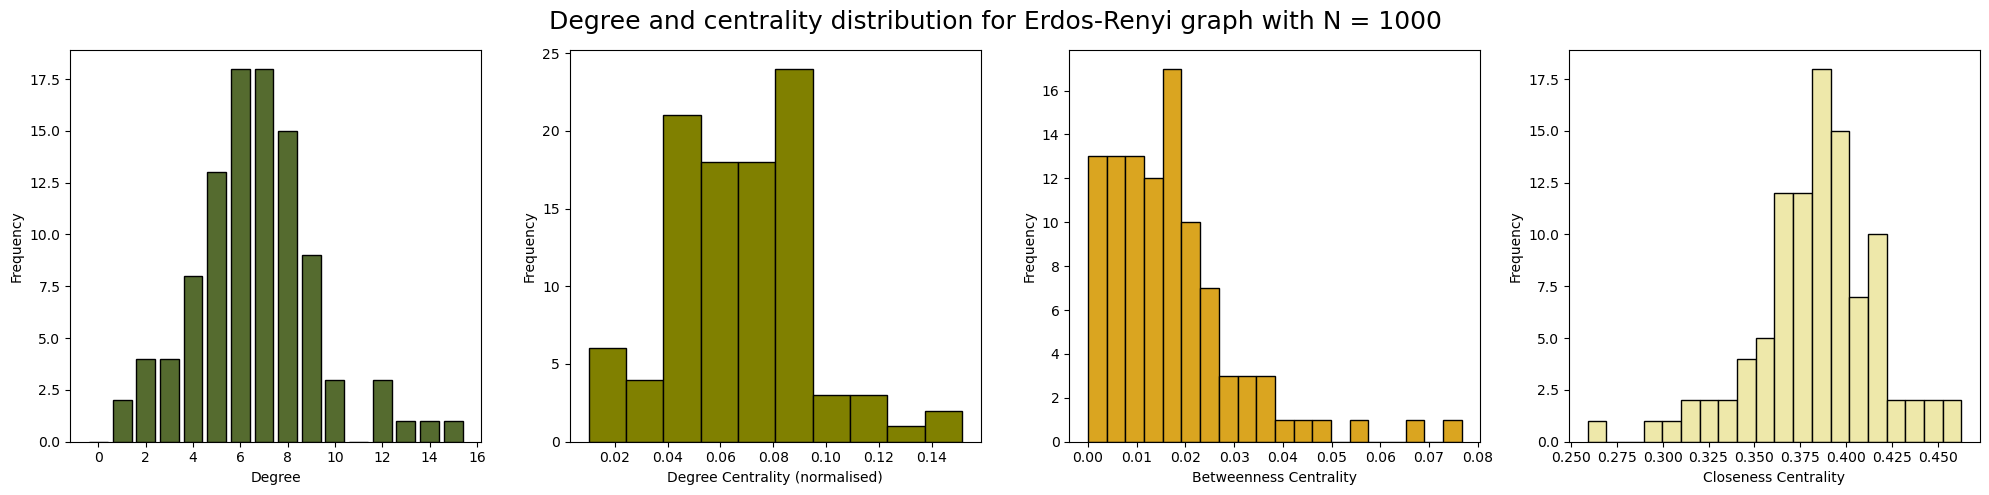

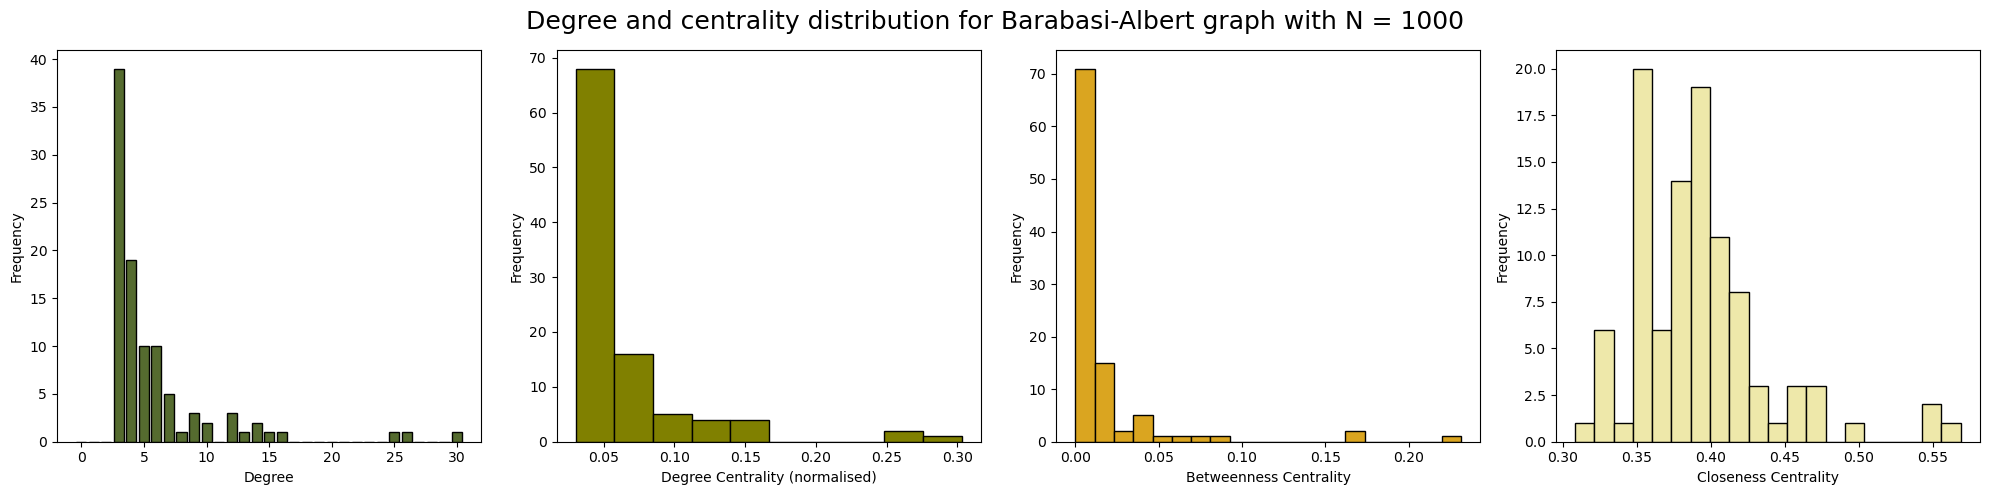

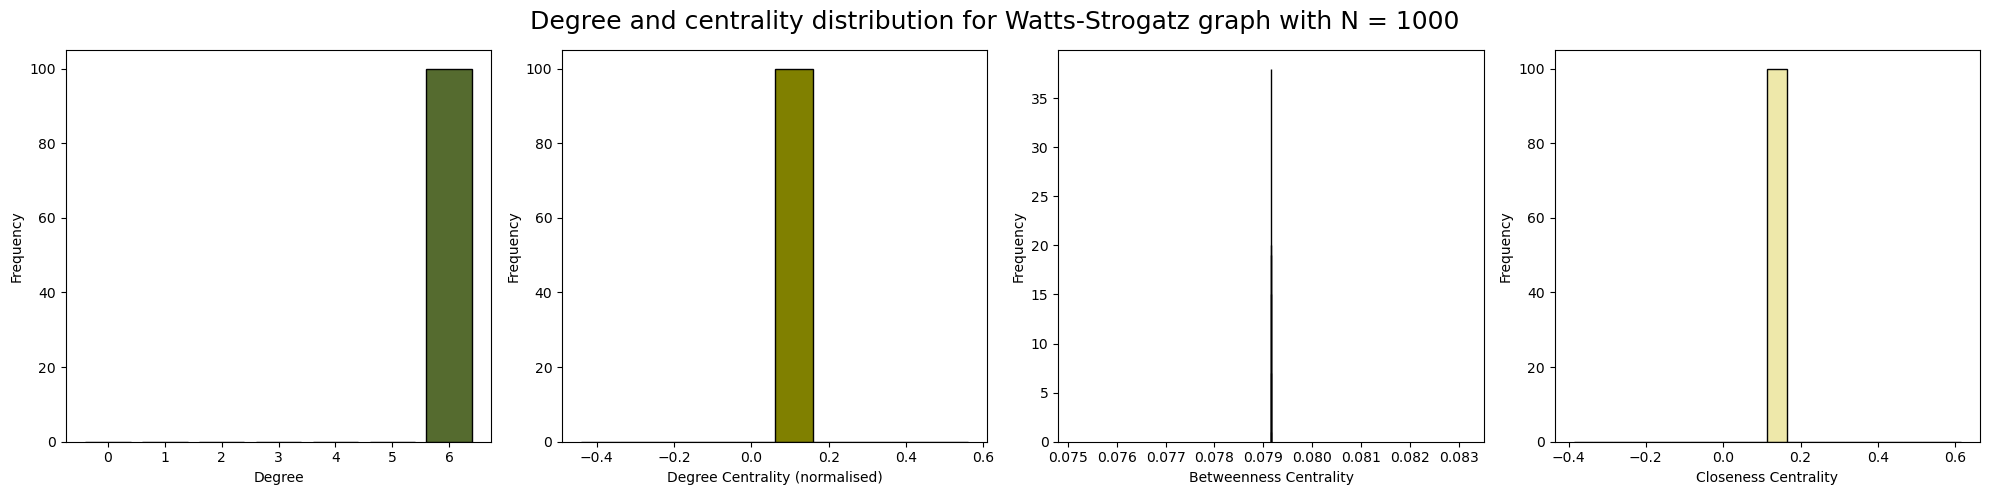

In [439]:
# Generate networks
seed = 10
num_nodes = 100

# Erdos-Renyi
er_network = create_network('Erdos-Renyi', num_nodes, seed = seed, p = 0.07)

# Barabasi-Albert
ba_network = create_network('Barabasi-Albert', num_nodes, seed = seed, m = 3)

# Watts-Strogatz
ws_network = create_network('Watts-Strogatz', num_nodes, seed = seed, k = 6, p = 0.001)

# Show statistics
print('Erdos-Renyi')
print_basic_network_statistics(er_network)
print('Barabasi-Albert')
print_basic_network_statistics(ba_network)
print('Watts-Strogatz')
print_basic_network_statistics(ws_network)

# Plot histograms
plot_network_histograms(er_network, 'Degree and centrality distribution for Erdos-Renyi graph with N = 1000')
plot_network_histograms(ba_network, 'Degree and centrality distribution for Barabasi-Albert graph with N = 1000')
plot_network_histograms(ws_network, 'Degree and centrality distribution for Watts-Strogatz graph with N = 1000')

## TESTING

In [268]:
# TESTING
# ER networks
network_type = 'Erdos-Renyi'
num_nodes = [100, 200, 400, 600, 800, 1000] # TODO: add more
probabilities = [0.1, 0.01, 0.001]

# Initialize results
average_degree = [[0 for _ in num_nodes] for _ in probabilities]
average_path_length = [[0 for _ in num_nodes] for _ in probabilities]
average_clustering = [[0 for _ in num_nodes] for _ in probabilities]

for i, p in enumerate(probabilities):
    for j, n in enumerate(num_nodes):
        network = create_network(network_type, n, p = p)        
        average_degree[i][j] = get_average_degree(network)
        average_clustering[i][j] = get_average_clustering(network)
    
        # We get an error in case of a graph that is not (strongly) connected
        try:
            average_path_length[i][j] = get_average_path_length(network)
        except nx.NetworkXError:
            # Set the path lenght to be 0
            average_path_length[i][j] = 0

In [233]:
# TESTING
# ER networks
network_type = 'Erdos-Renyi'
num_nodes = [100, 200, 400, 600, 800, 1000] # TODO: add more
probabilities = [0.1, 0.01, 0.001]

# Initialize results
average_degree_er = [[0 for _ in num_nodes] for _ in probabilities]

for i, p in enumerate(probabilities):
    for j, n in enumerate(num_nodes):
        network = create_network(network_type, n, p = p)
        
        average_degree_er[i][j] = get_average_degree(network)

In [237]:
# TESTING
# BA network
network_type = 'Barabasi-Albert'
num_nodes = [100, 200, 400, 600, 800, 1000] # TODO: add more
num_edges = [1, 5, 10]

# Initialize results
average_degree_ba = [[0 for _ in num_nodes] for _ in num_edges]

for i, m in enumerate(num_edges):
    for j, n in enumerate(num_nodes):
        network = create_network(network_type, n, m = m)
        
        average_degree_ba[i][j] = get_average_degree(network)

In [259]:
# TESTING
# WS network
network_type = 'Watts-Strogatz'
num_nodes = [100, 200, 400, 600, 800, 1000] # TODO: add more
num_neighbours = [2, 5, 10]
p = 0.01

# Initialize results
average_degree_ws = [[0 for _ in num_nodes] for _ in num_edges]

for i, k in enumerate(num_neighbours):
    for j, n in enumerate(num_nodes):
        network = create_network(network_type, n, p = p, k = k)
        
        average_degree_ws[i][j] = get_average_degree(network)

In [ ]:
# TESTING
beta = 1/7
gamma = 1/10
iterations = 100

network = create_network('Erdos-Renyi', 1000, seed = 10, p = 0.005)

trends = run_sir_simulations(network, beta, gamma, initial_infected_nodes = [1,2,3,4,5], iterations = 100, num_simulations = 50)

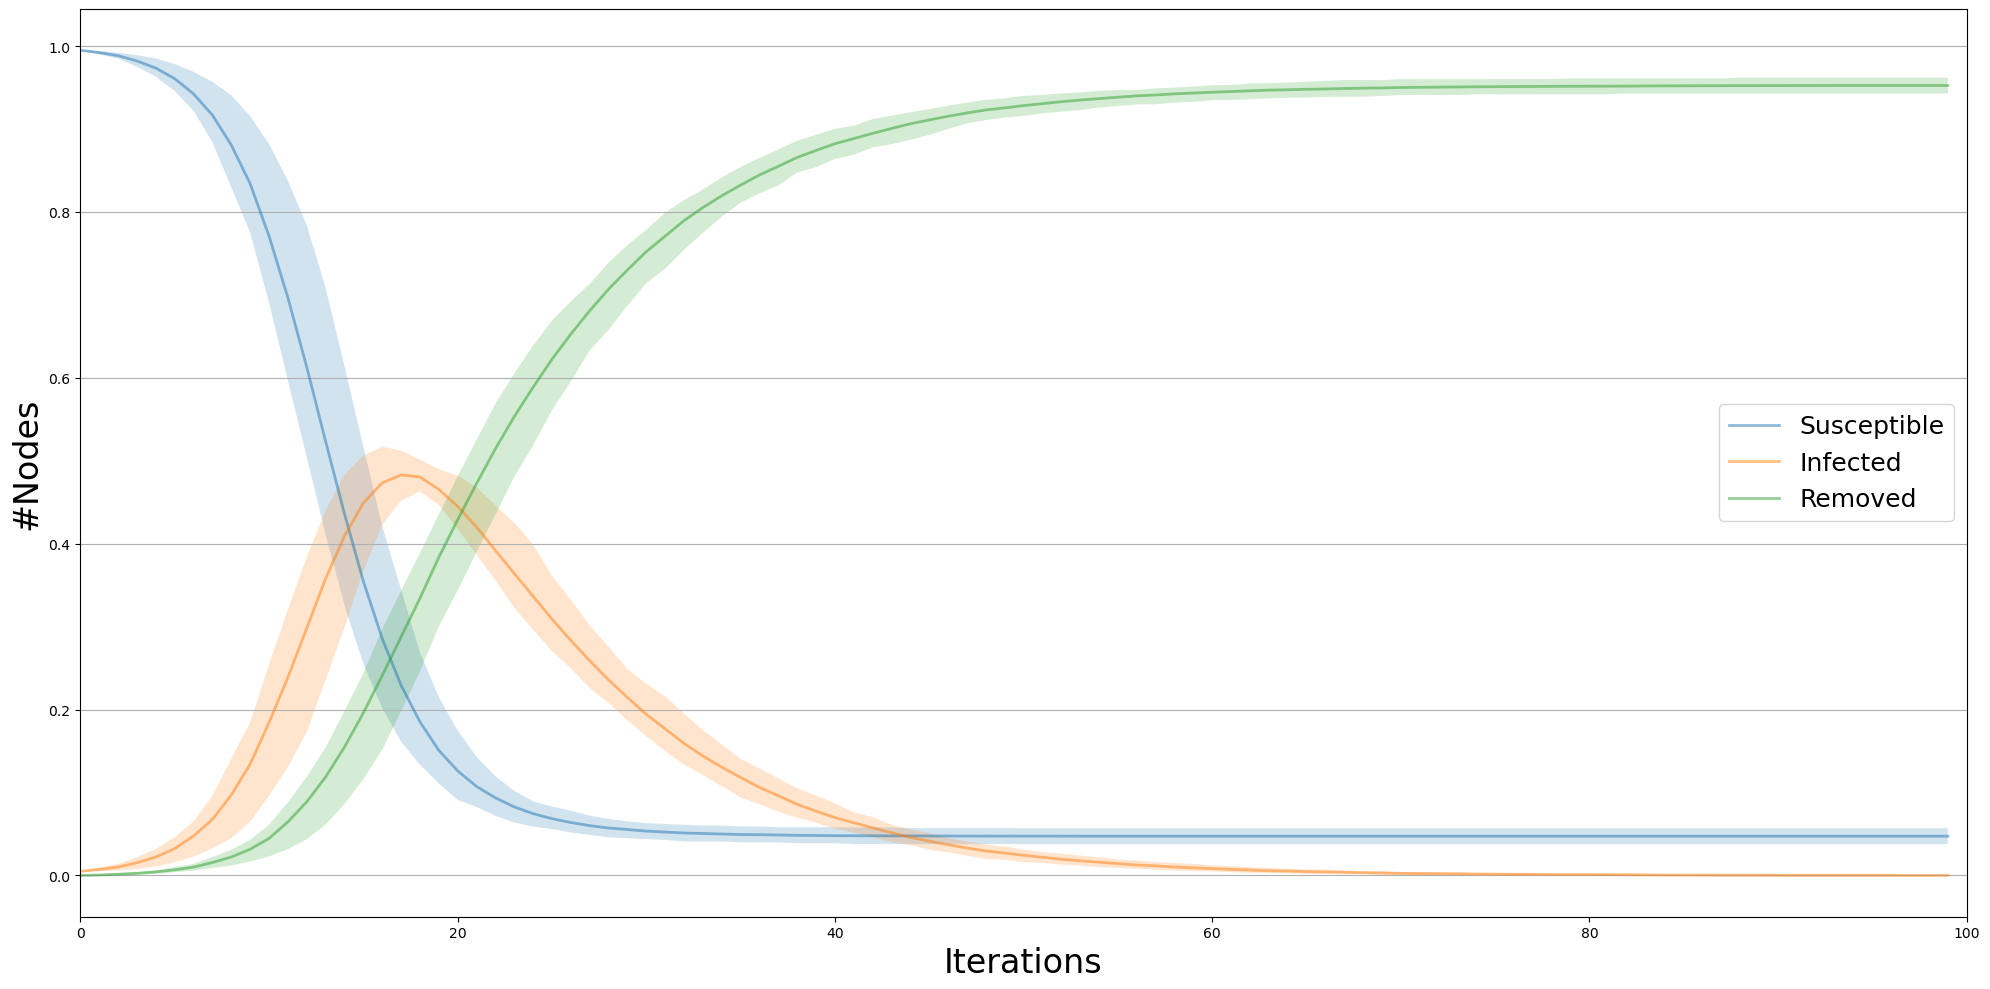

In [91]:
%matplotlib inline
from ndlib.viz.mpl.DiffusionTrend import DiffusionTrend

viz = DiffusionTrend(model, trends)
viz.plot()

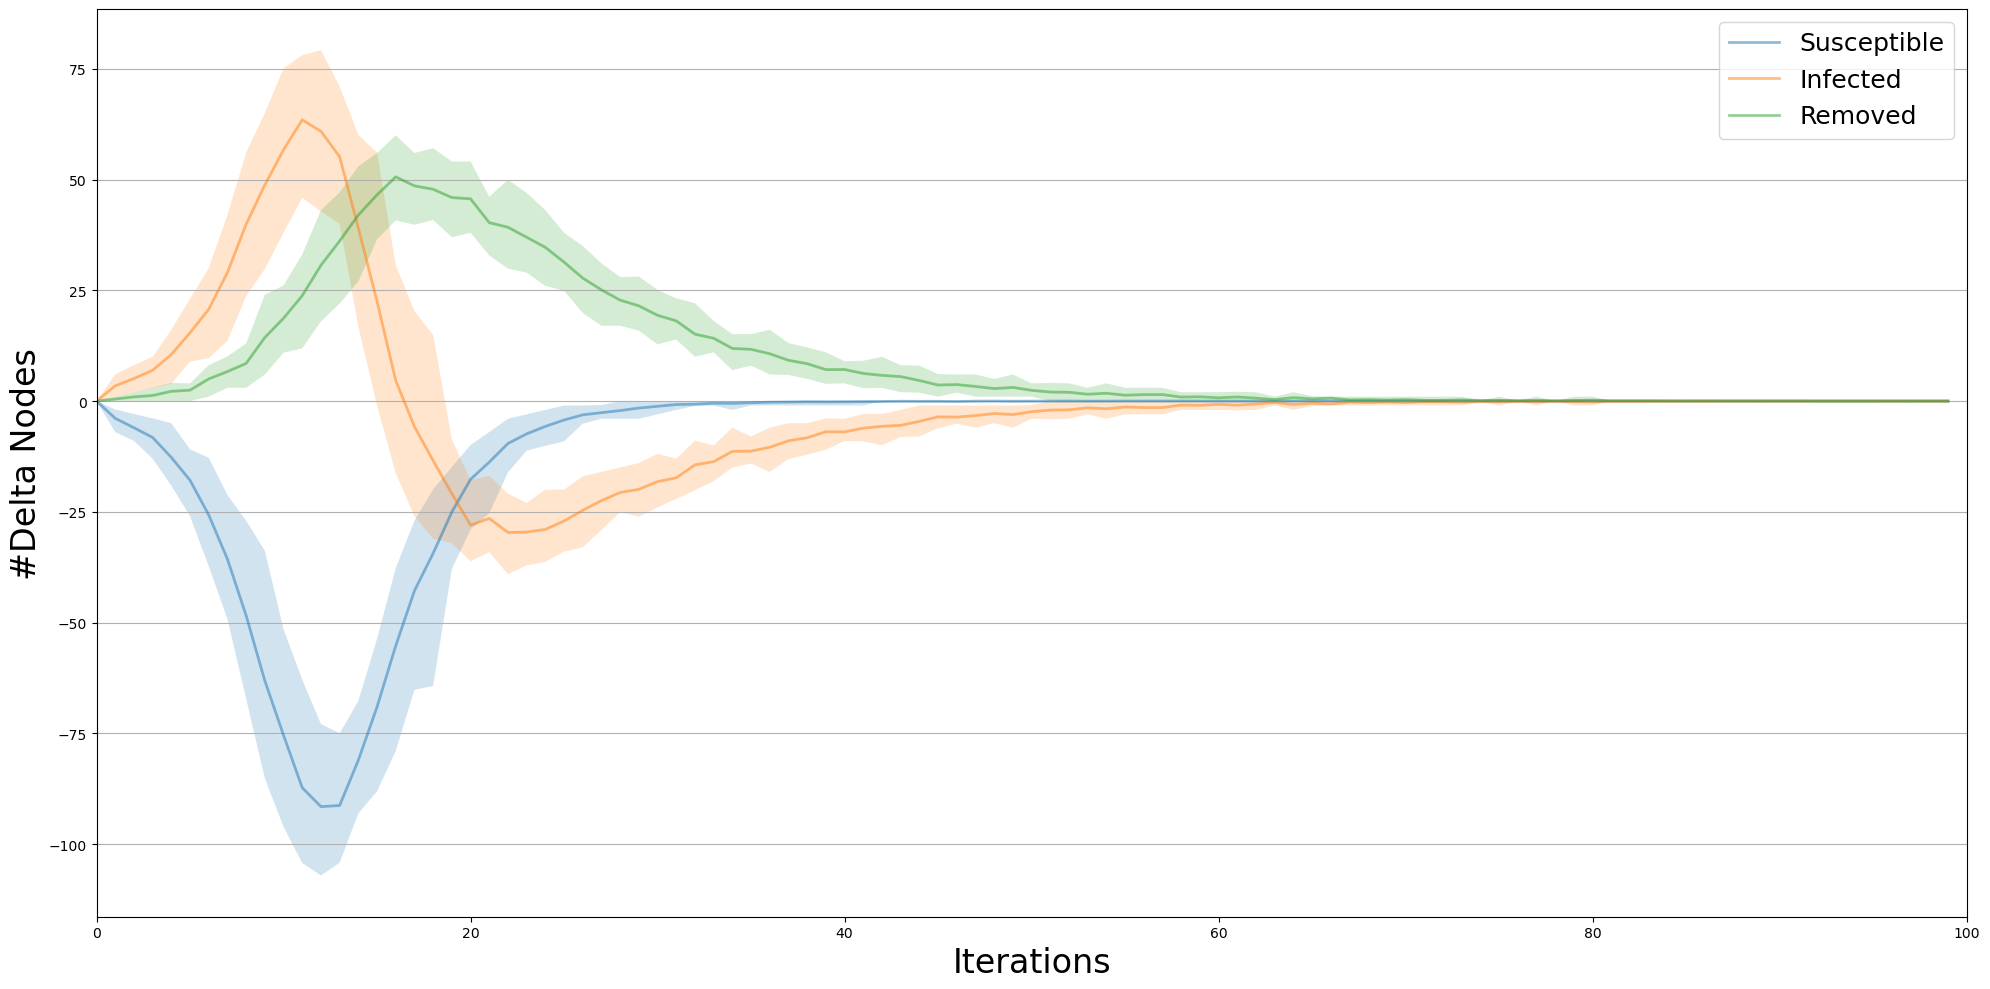

In [75]:
from ndlib.viz.mpl.DiffusionPrevalence import DiffusionPrevalence
viz = DiffusionPrevalence(model, trends)
viz.plot()